In [15]:
#import librarys


import pandas as pd
from scipy.stats import ttest_ind

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load_data

df=pd.read_csv("divar.csv")


C:\Users\Amin\AppData\Local\Temp\ipykernel_2992\3811003501.py:3: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("divar.csv")


In [5]:
barbecue=df["has_barbecue"]

pool=df["has_pool"]

jacuzzi=df["has_jacuzzi"]

sauna=df["has_sauna"]

barbecue.isnull().sum()

jacuzzi.isnull().sum()

pool.isnull().sum()

sauna.isnull().sum()

barbecue.value_counts()

jacuzzi.value_counts()

sauna.value_counts()

pool.value_counts()



has_pool
False    25669
True      3721
Name: count, dtype: int64

In [9]:
luxury_count = (
    (barbecue == True) &
    (pool == True) &
    (sauna == True) &
    (jacuzzi == True)
).sum()




df_analysis = df[
    (df["price_value"] > 0) &
    (df["price_value"] < 1e12) &
    (barbecue.notna()) &
    (pool.notna()) &
    (sauna.notna()) &
    (jacuzzi.notna())
]

analysis_count = len(df_analysis)


df_analysis["is_luxury"] = (
    (df_analysis["has_barbecue"] == True) &
    (df_analysis["has_pool"] == True) &
    (df_analysis["has_sauna"] == True) &
    (df_analysis["has_jacuzzi"] == True)
)

luxury_counts = df_analysis["is_luxury"].value_counts()



C:\Users\Amin\AppData\Local\Temp\ipykernel_2992\2010354183.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis["is_luxury"] = (


In [10]:
luxury_mean = df_analysis[df_analysis.is_luxury == True]["price_value"].mean()

non_luxury_mean = df_analysis[df_analysis.is_luxury == False]["price_value"].mean()

with open("result.txt", "a", encoding="utf-8") as f:
    f.write("\nAverage price by luxury classification:\n")
    f.write(f"Luxury mean price: {luxury_mean}\n")
    f.write(f"Non-luxury mean price: {non_luxury_mean}\n")

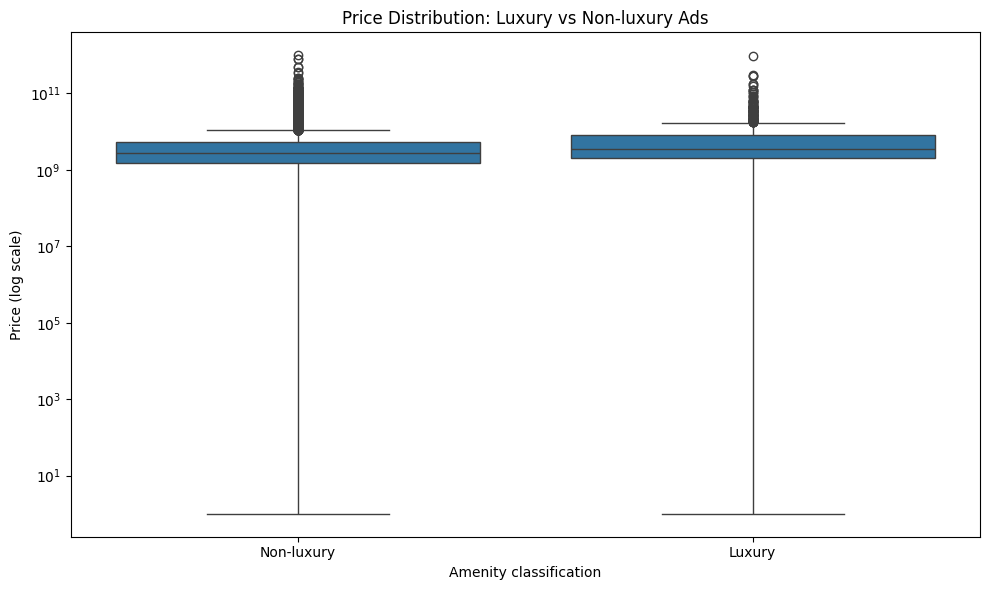

In [12]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_analysis,
    x="is_luxury",
    y="price_value"
)

plt.yscale("log")

plt.xticks(
    [0, 1],
    ["Non-luxury", "Luxury"]
)

plt.xlabel("Amenity classification")
plt.ylabel("Price (log scale)")
plt.title("Price Distribution: Luxury vs Non-luxury Ads")

plt.tight_layout()
plt.savefig("amin_rafi.png", dpi=300)
plt.show()

In [13]:
luxury_prices = df_analysis[
    df_analysis["is_luxury"] == True
]["price_value"]

non_luxury_prices = df_analysis[
    df_analysis["is_luxury"] == False
]["price_value"]

luxury_mean = luxury_prices.mean()
luxury_median = luxury_prices.median()
luxury_std = luxury_prices.std()

non_luxury_mean = non_luxury_prices.mean()
non_luxury_median = non_luxury_prices.median()
non_luxury_std = non_luxury_prices.std()

with open("result.txt", "a", encoding="utf-8") as f:
    f.write("\nDescriptive statistics by luxury classification:\n")

    f.write("\nLuxury:\n")
    f.write(f"Count: {len(luxury_prices)}\n")
    f.write(f"Mean: {luxury_mean}\n")
    f.write(f"Median: {luxury_median}\n")
    f.write(f"Standard deviation: {luxury_std}\n")

    f.write("\nNon-luxury:\n")
    f.write(f"Count: {len(non_luxury_prices)}\n")
    f.write(f"Mean: {non_luxury_mean}\n")
    f.write(f"Median: {non_luxury_median}\n")
    f.write(f"Standard deviation: {non_luxury_std}\n")

In [ ]:
luxury_prices = df_analysis[
    df_analysis["is_luxury"] == True
]["price_value"]

non_luxury_prices = df_analysis[
    df_analysis["is_luxury"] == False
]["price_value"]

t_stat, p_value = ttest_ind(
    luxury_prices,
    non_luxury_prices,
    equal_var=False
)



برای بررسی تأثیر امکانات لاکچری بر قیمت، آگهی‌ها بر اساس وجود هم‌زمان چهار امکان استخر، باربیکیو، سونا و جکوزی به دو گروه «لاکچری» و «غیرلاکچری» تقسیم شدند. همچنین برای جلوگیری از تأثیر مقادیر نامعتبر، تنها آگهی‌هایی با قیمت معتبر و اطلاعات کامل مربوط به امکانات مورد بررسی قرار گرفتند.
در این تحلیل، ۸۱۹ آگهی در گروه لاکچری و ۱۸٬۳۴۹ آگهی در گروه غیرلاکچری قرار گرفتند. میانگین قیمت در گروه لاکچری حدود ۱۱٫۱۵ میلیارد و در گروه غیرلاکچری حدود ۵٫۶ میلیارد بود. بنابراین میانگین قیمت آگهی‌های دارای امکانات لاکچری تقریباً دو برابر آگهی‌های غیرلاکچری است.
برای بررسی اینکه آیا این تفاوت میانگین از نظر آماری معنادار است، از آزمون Welch's t-test استفاده شد. مقدار آماره آزمون برابر با 3.87 و مقدار p-value برابر با 0.000116 به دست آمد. از آنجا که مقدار p-value بسیار کمتر از سطح معناداری 0.05 است، فرض صفر مبنی بر نبود تفاوت معنادار بین میانگین قیمت دو گروه رد می‌شود.
بنابراین، در این داده‌ها تفاوت میانگین قیمت آگهی‌های لاکچری و غیرلاکچری از نظر آماری معنادار است. با این حال، با توجه به پراکندگی و چولگی بالای قیمت‌ها، این نتیجه صرفاً نشان‌دهنده وجود تفاوت آماری بین میانگین دو گروه است و نباید آن را به‌تنهایی به معنای تعیین میزان اثر امکانات لاکچری بر قیمت در نظر گرفت.